<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

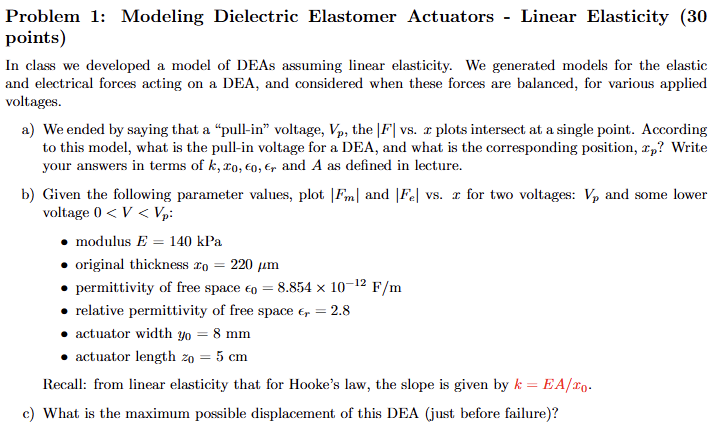

Problem 1 - Part B
---

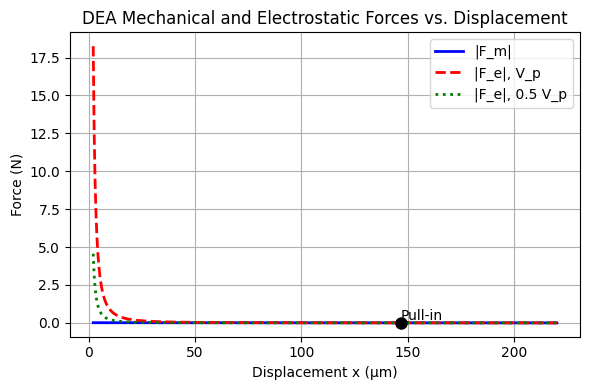

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
epsilon_0 = 8.854e-12  # F/m (vacuum permittivity)
epsilon_r = 2.8        # relative permittivity
E = 140e3              # Pa (Young's modulus)
x0 = 220e-6            # m (initial displacement / gap)
y0 = 8e-3              # m
z0 = 5e-2              # m

# --- Geometry and mechanical stiffness ---
A = y0 * z0            # Electrode area (m²)
k = E * A              # Spring constant (N/m)

# --- Pull-in voltage parameters ---
xp = (2 / 3) * x0
Vp = np.sqrt(k * (8 / 27) * x0**3 / (epsilon_0 * epsilon_r * A))

# --- Displacement range (avoid x = 0 singularity) ---
x = np.linspace(0.01 * x0, x0, 500)

# --- Mechanical restoring force ---
Fm = k * (x0 - x)

# --- Electrostatic forces ---
Fe_Vp = 0.5 * epsilon_0 * epsilon_r * A * Vp**2 / x**2        # At Vp
Fe_V1 = 0.5 * epsilon_0 * epsilon_r * A * (0.5 * Vp)**2 / x**2  # At 0.5 Vp

# --- Plotting ---
plt.figure(figsize=(6, 4))
plt.plot(x * 1e6, np.abs(Fm), 'b', linewidth=2, label='|F_m|')
plt.plot(x * 1e6, np.abs(Fe_Vp), 'r--', linewidth=2, label='|F_e|, V_p')
plt.plot(x * 1e6, np.abs(Fe_V1), 'g:', linewidth=2, label='|F_e|, 0.5 V_p')

# Pull-in point marker
plt.plot(xp * 1e6, k * (x0 - xp), 'ko', markerfacecolor='k', markersize=8)
plt.text(xp * 1e6, k * (x0 - xp), 'Pull-in', verticalalignment='bottom', fontsize=10)

# --- Labels, legend, formatting ---
plt.xlabel('Displacement x (μm)')
plt.ylabel('Force (N)')
plt.title('DEA Mechanical and Electrostatic Forces vs. Displacement')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


Problem 2 - Part B
---

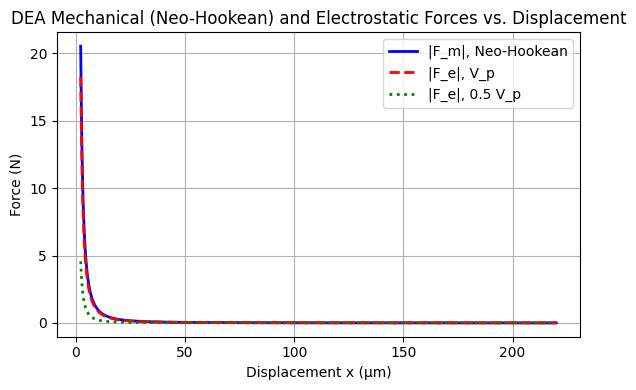

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
epsilon_0 = 8.854e-12  # F/m (vacuum permittivity)
epsilon_r = 2.8        # relative permittivity
E = 140e3              # Pa (Young's modulus)
x0 = 220e-6            # m (initial gap)
y0 = 8e-3              # m
z0 = 5e-2              # m

# --- Area and Neo-Hookean constant ---
A = y0 * z0            # m²
C1 = E / 6             # Neo-Hookean constant

# --- Spring constant (used for Vp only) ---
k = E * A

# --- Pull-in parameters ---
xp = (2 / 3) * x0
Vp = np.sqrt(k * (8 / 27) * x0**3 / (epsilon_0 * epsilon_r * A))

# --- Displacement range ---
x = np.linspace(0.01 * x0, x0, 500)  # avoid division by zero

# --- Neo-Hookean Mechanical Force ---
lambda1 = x / x0
Fm_NH = -C1 * x0 * A * (lambda1 - 1 / lambda1**2)

# --- Electrostatic Forces ---
Fe_Vp = 0.5 * epsilon_0 * epsilon_r * A * Vp**2 / x**2        # At Vp
Fe_V1 = 0.5 * epsilon_0 * epsilon_r * A * (0.5 * Vp)**2 / x**2  # At 0.5 Vp

# --- Plotting ---
plt.figure(figsize=(6, 4))
plt.plot(x * 1e6, np.abs(Fm_NH), 'b', linewidth=2, label='|F_m|, Neo-Hookean')
plt.plot(x * 1e6, np.abs(Fe_Vp), 'r--', linewidth=2, label='|F_e|, V_p')
plt.plot(x * 1e6, np.abs(Fe_V1), 'g:', linewidth=2, label='|F_e|, 0.5 V_p')

# --- Labels, legend, grid ---
plt.xlabel('Displacement x (μm)')
plt.ylabel('Force (N)')
plt.title('DEA Mechanical (Neo-Hookean) and Electrostatic Forces vs. Displacement')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


Problem 2 - Part C
---

In [6]:
import numpy as np
from scipy.optimize import fsolve

# Constants
epsilon_0 = 8.854e-12  # F/m
epsilon_r = 2.8
E = 140e3              # Pa
x0 = 220e-6            # m
y0 = 8e-3              # m
z0 = 5e-2              # m

A = y0 * z0            # m^2
C1 = E / 2             # Neo-Hookean constant
k = E * A              # Linear spring constant

# Pull-in voltage
Vp = np.sqrt(k * (8 / 27) * x0**3 / (epsilon_0 * epsilon_r * A))

# Define the force balance: Fm - Fe = 0
def equilibrium_eq(x):
    lambda1 = x / x0
    Fm = -C1 * x0 * A * (lambda1 - 1 / lambda1**2)
    Fe = 0.5 * epsilon_0 * epsilon_r * A * Vp**2 / x**2
    return Fm - Fe

# Initial guess near x0
x_guess = 0.95 * x0

# Solve
x_solution = fsolve(equilibrium_eq, x_guess)[0]
d_neo_hookean = x0 - x_solution

# Convert to micrometers
x_solution_um = x_solution * 1e6
d_neo_hookean_um = d_neo_hookean * 1e6

# Print results
print(f"Neo-Hookean pull-in point: x = {x_solution_um:.2f} µm")
print(f"Displacement from x0: {d_neo_hookean_um:.2f} µm")


Neo-Hookean pull-in point: x = 195.68 µm
Displacement from x0: 24.32 µm


Problem 3 - Part B
---

Sample (L [mm], V [V]):
8.00 mm -> nan V
8.20 mm -> 1135.7 V
8.40 mm -> 1596.7 V
8.60 mm -> 1944.4 V
8.80 mm -> 2232.8 V


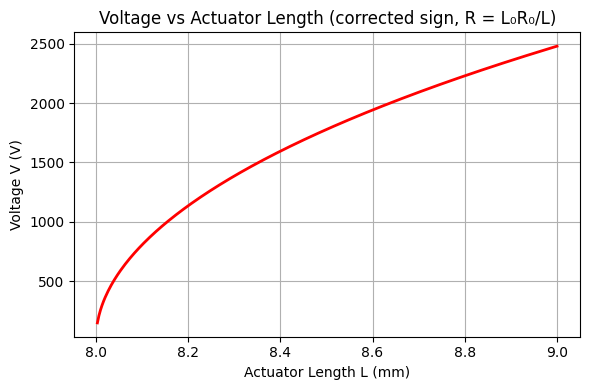

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters ---
E = 140e3           # Pa
t0 = 220e-6         # m
eps0 = 8.854e-12    # F/m
epsr = 2.8
L0 = 8e-3           # m
n = 7
c1 = E / 6.0        # Neo-Hookean constant

# --- Corrected Voltage function (with negative sign fixed) ---
def V_of_L(L):
    val = (4 * c1 * t0**2 * (L**2 - L0**2)) / (n * eps0 * epsr * L * L0)
    val = np.where(val > 0, np.sqrt(val), np.nan)
    return val

# --- Compute and plot ---
L_vals = np.linspace(8e-3, 9e-3, 300)
V_vals = V_of_L(L_vals)

print("Sample (L [mm], V [V]):")
for lmm, v in list(zip(L_vals*1e3, V_vals))[::60]:
    print(f"{lmm:.2f} mm -> {v:.1f} V")

plt.figure(figsize=(6,4))
plt.plot(L_vals*1e3, V_vals, 'r', linewidth=2)
plt.xlabel("Actuator Length L (mm)")
plt.ylabel("Voltage V (V)")
plt.title("Voltage vs Actuator Length (corrected sign, R = L₀R₀/L)")
plt.grid(True)
plt.tight_layout()
plt.show()


Problem 3 - Part C
---


In [9]:
import numpy as np

# --- Given parameters ---
E = 140e3           # Pa
t0 = 220e-6         # m
eps0 = 8.854e-12    # F/m
epsr = 2.8
L0 = 8e-3           # m
n = 7
c1 = E / 6.0        # Neo-Hookean constant

# --- Desired elongation ---
delta_L = 1e-3      # 1 mm extension
L = L0 + delta_L    # Final length

# --- Voltage formula ---
def V_required(L):
    val = (4 * c1 * t0**2 * (L**2 - L0**2)) / (n * eps0 * epsr * L * L0)
    if val < 0:
        raise ValueError("Negative value under square root — check sign convention.")
    return np.sqrt(val)

# --- Compute voltage ---
V = V_required(L)

# --- Display result ---
print(f"Initial length L0 = {L0*1e3:.1f} mm")
print(f"Final length L = {L*1e3:.1f} mm")
print(f"Elongation ΔL = {delta_L*1e3:.1f} mm")
print(f"Required applied voltage = {V:.2f} V ({V/1000:.2f} kV)")


Initial length L0 = 8.0 mm
Final length L = 9.0 mm
Elongation ΔL = 1.0 mm
Required applied voltage = 2479.14 V (2.48 kV)


Problem 3 - Part D
---

In [10]:
import numpy as np

E = 140e3           # Pa
t0 = 220e-6         # m
eps0 = 8.854e-12    # F/m
epsr = 2.8
L0 = 8e-3           # m
n = 7
c1 = E / 6.0

def V_of_L(L):
    val = (4 * c1 * t0**2 * (L**2 - L0**2)) / (n * eps0 * epsr * L * L0)
    val = np.where(val > 0, np.sqrt(val), np.nan)
    return val

L_vals = np.linspace(8e-3, 9e-3, 300)
V_vals = V_of_L(L_vals)

V_pullin = np.nanmax(V_vals)
L_pullin = L_vals[np.nanargmax(V_vals)]

print(f"Predicted steady-state pull-in voltage: {V_pullin:.2f} V")
print(f"Occurs at actuator length: {L_pullin*1e3:.2f} mm")


Predicted steady-state pull-in voltage: 2479.14 V
Occurs at actuator length: 9.00 mm
